# Работу выполнил студент ДПИ25-1 Карчевский Андрей

## Визуализация данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

## Разминка

1. При помощи пакета `pandas_datareader` загружаем данные о ценах акций Apple с 2017-01-01 по 2018-12-31. Визуализируем временные ряд цен акций.

In [6]:
pip install pandas_datareader --break-system-packages

Note: you may need to restart the kernel to use updated packages.


### С pandas_datareader не получилось сделать, использовал библиотеку yfinance

In [7]:
# Загружаем данные по акциям Apple (AAPL) за 2017-01-01 — 2018-12-31 и строим временной ряд цен.
from pandas_datareader import data as pdr

start = "2017-01-01"
end = "2018-12-31"

# Источник 'stooq' доступен без ключей/авторизации
aapl = pdr.DataReader("AAPL", "stooq", start=start, end=end).sort_index()

display(aapl.head())

plt.figure(figsize=(12, 4))
plt.plot(aapl.index, aapl["Close"])
plt.title("Временной ряд цены закрытия акций Apple (AAPL), 2017–2018")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия, USD")
plt.grid(True, alpha=0.3)
plt.show()


ModuleNotFoundError: No module named 'distutils'

[*********************100%***********************]  1 of 1 completed

Price       Adj Close      Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                                        
2017-01-03  26.745857  29.037500  29.082500  28.690001  28.950001  115127600
2017-01-04  26.715919  29.004999  29.127501  28.937500  28.962500   84472400
2017-01-05  26.851780  29.152500  29.215000  28.952499  28.980000   88774400
2017-01-06  27.151133  29.477501  29.540001  29.117500  29.195000  127007600
2017-01-09  27.399826  29.747499  29.857500  29.485001  29.487499  134247600


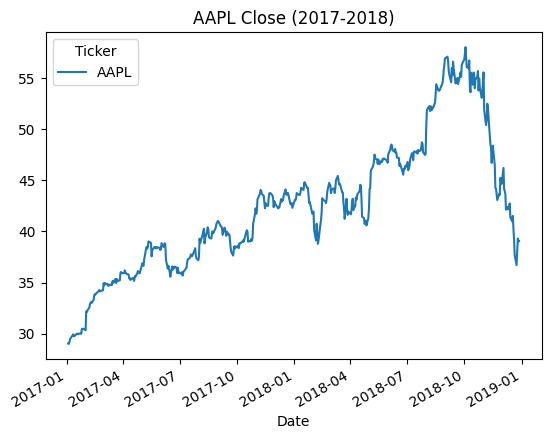

In [8]:
import yfinance as yf
import matplotlib.pyplot as plt

start = "2017-01-01"
end = "2018-12-31"

df = yf.download("AAPL", start=start, end=end, auto_adjust=False)  # OHLCV
print(df.head())

df["Close"].plot(title="AAPL Close (2017-2018)")
plt.show()

Найдено выбросов по правилу IQR: 501


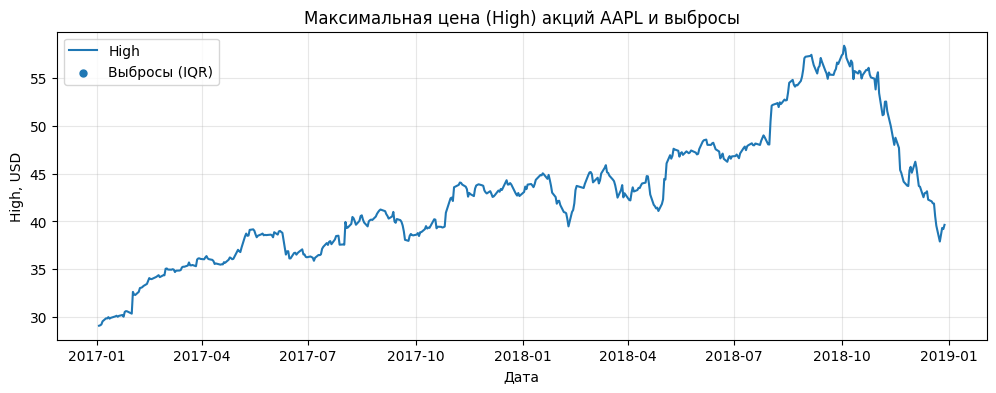

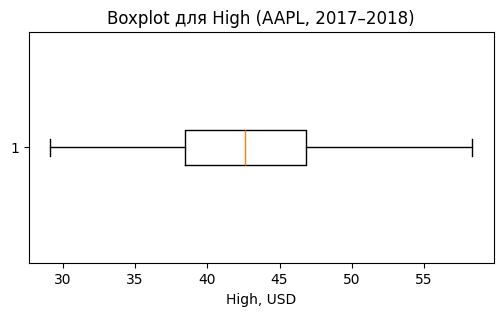

In [10]:
# Анализируем временной ряд максимальной цены (High) на предмет выбросов:
# используем правило межквартильного размаха (IQR) и визуально отмечаем точки-выбросы.
high = df["High"].dropna()

q1 = high.quantile(0.25)
q3 = high.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = high[(high < lower) | (high > upper)]
print(f"Найдено выбросов по правилу IQR: {len(outliers)}")

plt.figure(figsize=(12, 4))
plt.plot(high.index, high.values, label="High")
plt.scatter(outliers.index, outliers.values, marker="o", s=25, label="Выбросы (IQR)")
plt.title("Максимальная цена (High) акций AAPL и выбросы")
plt.xlabel("Дата")
plt.ylabel("High, USD")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Дополнительно: коробчатая диаграмма для оценки распределения High
plt.figure(figsize=(6, 3))
plt.boxplot(high.values, vert=False)
plt.title("Boxplot для High (AAPL, 2017–2018)")
plt.xlabel("High, USD")
plt.show()


## Лабораторная работа 5.1

__Данная работа подразумевает построение рисунков. В связи с этим задания, для которых не будет виден результат выполнения ячеек (получившиеся рисунки), засчитаны не будут вне зависимости от правильности решения.__

### Визуализация данных при помощи пакета `matplotlib`

__В данном блоке задач не разрешается использовать другие пакеты для визуализации, кроме `matplotlib`.__

1\. В файле `average_ratings.npy` содержится информация о среднем рейтинге 3 рецептов за период с 01.01.2019 по 30.12.2021. При помощи пакета `matplotlib` в _одной системе координат_ (на одной картинке) изобразите три временных ряда, соответствующих средним рейтингам этих рецептов. 

По горизонтальной оси располагается номер дня (0, 1, 2, ...), по вертикальной - средний рейтинг рецептов в этот день. 

Названия рецептов и их индексы в файле `average_ratings.npy`:
```
0: waffle iron french toast
1: zwetschgenkuchen bavarian plum cake
2: lime tea
```

Результатом работы является визуализация, на которой:
* добавлена подпись горизонтальной оси с текстом "Номер дня"
* добавлена подпись вертикальной оси с текстом "Средний рейтинг"
* добавлена подпись рисунка с текстом "Изменение среднего рейтинга трех рецептов"
* каждый из временных рядов имеет уникальный цвет
* добавлена легенда, на которой отображается название каждого из рецептов

_Примечание_ : для считывания файла воспользуйтесь функцией `np.load`.

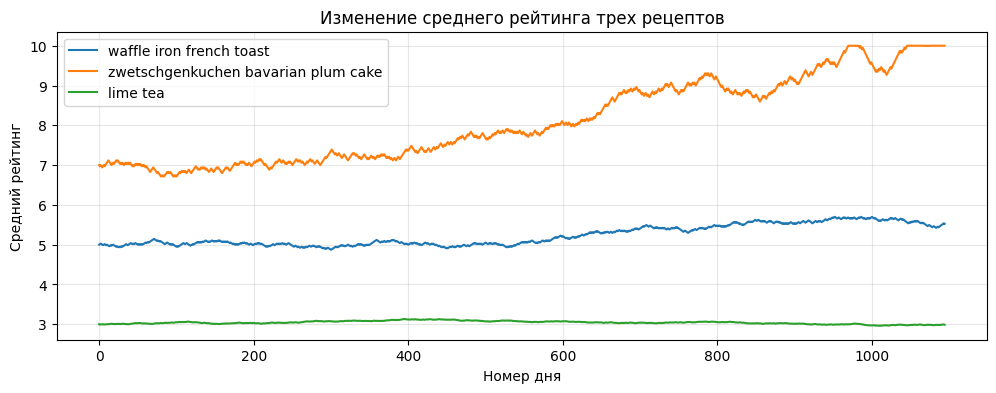

In [12]:
# Считываем данные со средними рейтингами и строим три временных ряда в одной системе координат.
avg = np.load("average_ratings.npy")  # ожидаем форму (3, N) или (N, 3)

# Приводим к форме (3, N) для удобства
if avg.shape[0] != 3 and avg.shape[1] == 3:
    avg = avg.T

names = [
    "waffle iron french toast",
    "zwetschgenkuchen bavarian plum cake",
    "lime tea",
]

plt.figure(figsize=(12, 4))
for i, name in enumerate(names):
    plt.plot(np.arange(avg.shape[1]), avg[i], label=name)

plt.xlabel("Номер дня")
plt.ylabel("Средний рейтинг")
plt.title("Изменение среднего рейтинга трех рецептов")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


2\. Измените визуализацию, полученную в задании 1, таким образом, чтобы по горизонтальной оси отображались года, а между двумя соседними годами располагались засечки, соответствующие месяцам. Для этого создайте диапазон дат от 01.01.2019 по 30.12.2021 с шагом в один день (например, [вот так](https://pandas.pydata.org/docs/reference/api/pandas.date_range.html)) и используйте этот диапазон при вызове метода `plot`. Далее настройте `major_locator` и `minor_locator` горизонтальной оси (подробнее см. [здесь](https://matplotlib.org/stable/gallery/text_labels_and_annotations/date.html))

Примените к получившемуся рисунку цвета графиков, подписи, легенду из задания 1. Измените подпись горизонтальной оси, написав там слово "Дата".


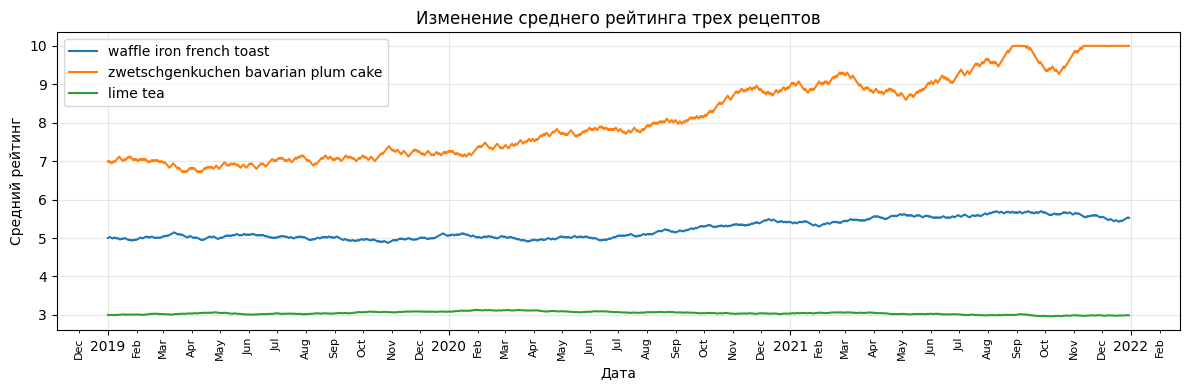

In [13]:
# Создаем диапазон дат и настраиваем отображение по годам (major ticks) и месяцам (minor ticks).
dates = pd.date_range("2019-01-01", "2021-12-30", freq="D")

plt.figure(figsize=(12, 4))
for i, name in enumerate(names):
    plt.plot(dates, avg[i], label=name)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

# Чтобы подписи месяцев не слипались, показываем их реже за счет поворота
plt.setp(ax.get_xticklabels(which="major"), rotation=0, ha="center")
plt.setp(ax.get_xticklabels(which="minor"), rotation=90, fontsize=8)

plt.xlabel("Дата")
plt.ylabel("Средний рейтинг")
plt.title("Изменение среднего рейтинга трех рецептов")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


3\. Измените визуализацию, полученную в задании 2, разбив одну картинку на три, расположенных друг под другом. Три изображения должны иметь одну общую горизонтальную ось (каждое изображение засечки в нижней части, но значения этих засечек находятся только под самым нижним изображением). Примените к получившемуся рисунку цвета графиков, подписи, легенду из задания 2. 

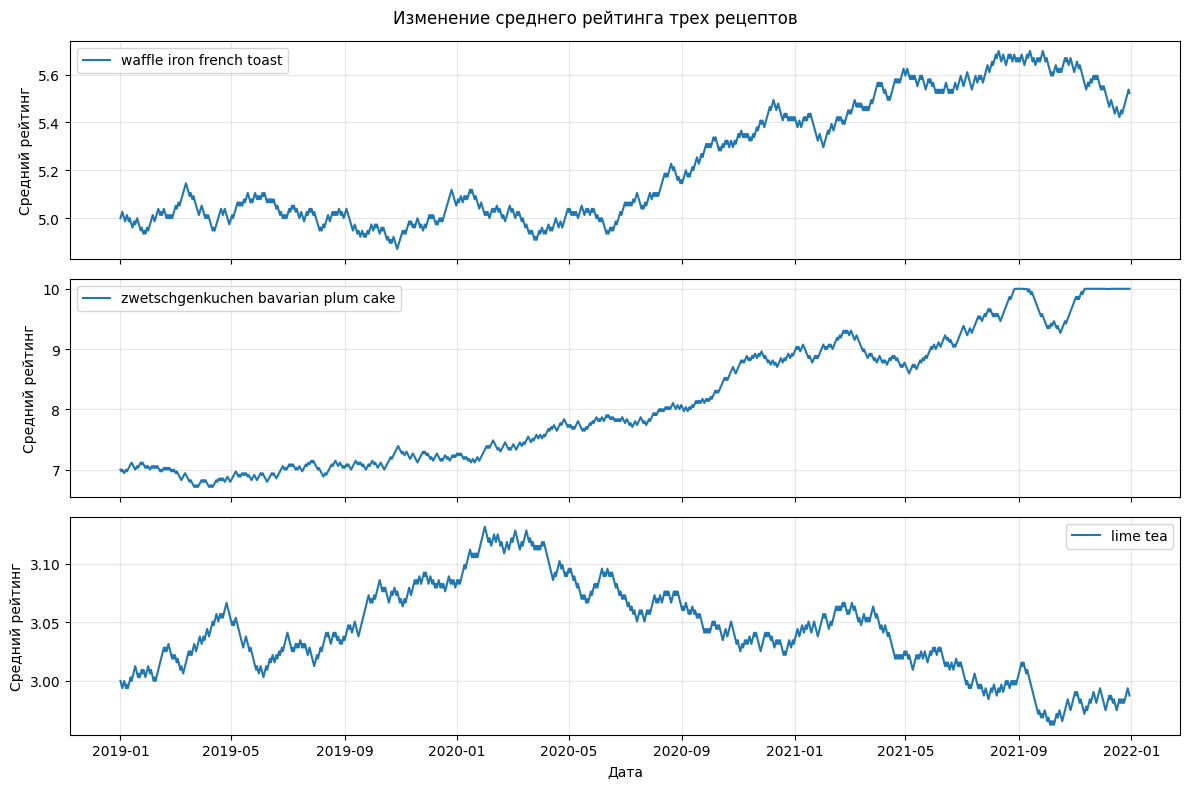

In [14]:
# Разбиваем график на три подграфика, расположенных вертикально, с общей горизонтальной осью.
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(dates, avg[i], label=names[i])
    ax.set_ylabel("Средний рейтинг")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes[-1].set_xlabel("Дата")
fig.suptitle("Изменение среднего рейтинга трех рецептов", y=0.98)
plt.tight_layout()
plt.show()


4\. В файле `visitors.npy` представлена информация о количестве посетителей сайта в течении первых 100 дней после объявления сайтом акции. Постройте график изменения количества пользователей в зависимости от дня в двух вариантах, расположенных рядом по горизонтале. В обоих случаях изобразите график в виде ломаной, но в первом случае оставьте линейный масштаб осей, а во втором случае сделайте вертикальную ось в логарифмическом масштабе. Добавьте на обе картинки подпись над этим графиком к текстом $y(x)=\lambda e^{-\lambda x}$

Добавьте на оба изображения красную горизонтальную линию на уровне $y=100$. Добавьте на обе картинки подпись над этой линией с текстом $y(x)=100$

Добавьте на оба изображения подписи осей; горизонтальную ось подпишите текстом "Количество дней с момента акции", вертикальную - "Число посетителей".

Добавьте общий заголовок для фигуры с текстом "Изменение количества пользователей в линейном и логарифмическом масштабе".


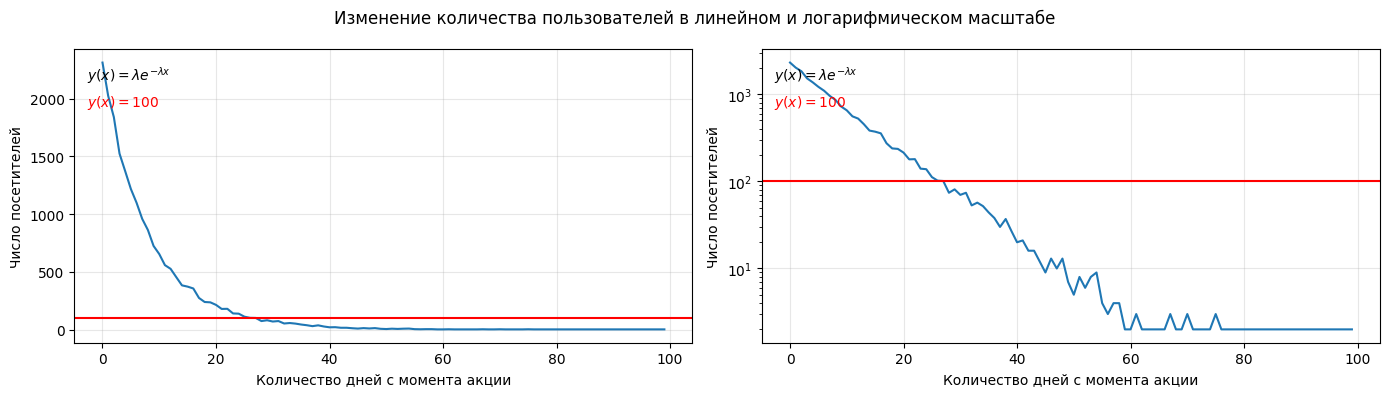

In [16]:
# Строим графики изменения числа посетителей в линейном и логарифмическом масштабе.
visitors = np.load("visitors.npy")
days = np.arange(len(visitors))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax in axes:
    ax.plot(days, visitors)
    ax.set_xlabel("Количество дней с момента акции")
    ax.set_ylabel("Число посетителей")
    ax.grid(True, alpha=0.3)

    # Подпись над графиком (как указано в задании)
    ax.text(0.02, 0.95, r"$y(x)=\lambda e^{-\lambda x}$", transform=ax.transAxes, va="top")

    # Горизонтальная линия y=100 + подпись
    ax.axhline(100, color="red")
    ax.text(0.02, 0.85, r"$y(x)=100$", transform=ax.transAxes, va="top", color="red")

axes[1].set_yscale("log")

fig.suptitle("Изменение количества пользователей в линейном и логарифмическом масштабе")
plt.tight_layout()
plt.show()


## Лабораторная работа 5.2

### Визуализация данных на основе структур `pandas`.

Для продолжения работы загрузите таблицы recipes и reviews (__ЛР2__)

In [17]:
# Загружаем таблицы recipes и reviews из файлов (выборка).
recipes = pd.read_csv("recipes_sample.csv")
reviews = pd.read_csv("reviews_sample.csv")

# Приводим дату к типу datetime для удобной фильтрации
reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")

display(recipes.head())
display(reviews.head())


,name,id,minutes,contributor_id,submitted,n_steps,description,n_ingredients
0,george s at the cove black bean soup,44123,90,35193,2002-10-25,NaN,an original recipe created by chef scott meska...,18.0
1,healthy for them yogurt popsicles,67664,10,91970,2003-07-26,NaN,my children and their friends ask for my homem...,NaN
2,i can t believe it s spinach,38798,30,1533,2002-08-29,NaN,"these were so go, it surprised even me.",8.0
3,italian gut busters,35173,45,22724,2002-07-27,NaN,my sister-in-law made these for us at a family...,NaN
4,love is in the air beef fondue sauces,84797,25,4470,2004-02-23,4.0,i think a fondue is a very romantic casual din...,NaN


,Unnamed: 0,user_id,recipe_id,date,rating,review
0,370476,21752,57993,2003-05-01,5,Last week whole sides of frozen salmon fillet ...
1,624300,431813,142201,2007-09-16,5,So simple and so tasty! I used a yellow capsi...
2,187037,400708,252013,2008-01-10,4,"Very nice breakfast HH, easy to make and yummy..."
3,706134,2001852463,404716,2017-12-11,5,These are a favorite for the holidays and so e...
4,312179,95810,129396,2008-03-14,5,Excellent soup! The tomato flavor is just gre...


5\. Назовем рецепты короткими, если они занимают строго меньше 5 минут; средними, если они занимают от 5 до 50 минут (не включая 50), и длинными, если они занимают от 50 минут и больше. Сгруппируйте все рецепты по данному признаку и для каждой группы посчитайте 2 величины: среднее количество шагов рецептов в группе и размер группы. При помощи методов структур `pandas` постройте столбчатую диаграмму, где каждый столбец означает группу (короткие, средние или длинные рецепты), а высота столбца обозначает среднее количество шагов рецептов в группе. Рядом по горизонтали разместите круговую диаграмму, на которой отображены размеры каждой из групп.

Добавьте следующие подписи:
* по горизонтальной оси под столбчатой диаграммой напишите "Группа рецептов"
* по вертикальной оси слева от столбчатой диаграммы напишите "Средняя длительность"
* над круговой диаграммой напишите "Размеры групп рецептов"

In [ ]:
# Категоризируем рецепты по длительности и строим bar + pie рядом.
def duration_group(minutes: float) -> str:
    if pd.isna(minutes):
        return np.nan
    if minutes < 5:
        return "короткие"
    if minutes < 50:
        return "средние"
    return "длинные"

recipes["duration_group"] = recipes["minutes"].apply(duration_group)

# Для среднего количества шагов используем только строки, где n_steps известен
tmp = recipes.dropna(subset=["duration_group", "n_steps"]).copy()

grp = tmp.groupby("duration_group").agg(
    mean_steps=("n_steps", "mean"),
    size=("duration_group", "size"),
)

# Чтобы группы шли в логичном порядке
order = ["короткие", "средние", "длинные"]
grp = grp.reindex(order)

display(grp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

grp["mean_steps"].plot(kind="bar", ax=axes[0])
axes[0].set_xlabel("Группа рецептов")
axes[0].set_ylabel("Средняя длительность")
axes[0].grid(True, axis="y", alpha=0.3)

grp["size"].plot(kind="pie", ax=axes[1], autopct="%.1f%%")
axes[1].set_ylabel("")  # убираем стандартную подпись оси у pie
axes[1].set_title("Размеры групп рецептов")

plt.tight_layout()
plt.show()


6\. Из всего множества отзывов оставьте только те, которые были даны в 2008 и 2009 годах. Воспользовавшись возможностями метода `pd.DataFrame.plot.hist`, постройте 2 гистограммы столбца `rating`. Гистограммы должны быть расположены рядом по горизонтали. Левая гистограмма соотвествует 2008 году, правая - 2009 году. Добавьте общую подпись для рисунка с текстом "Гистограммы рейтинга отзывов в 2008 и 2009 годах". Добейтесь того, чтобы подпись вертикальной оси правого рисунка не "наезжала" на левый рисунок.

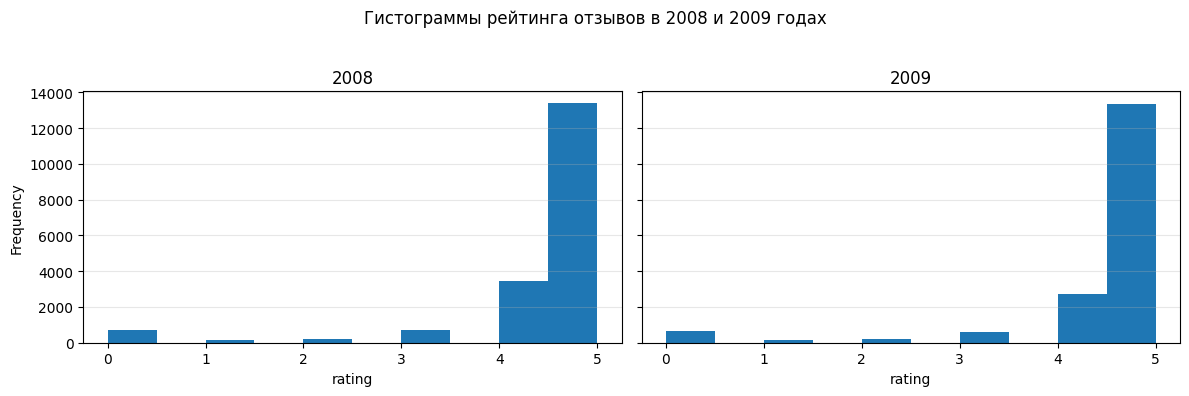

In [18]:
# Оставляем отзывы только за 2008 и 2009 годы и строим две гистограммы rating рядом.
reviews_08 = reviews[reviews["date"].dt.year == 2008]
reviews_09 = reviews[reviews["date"].dt.year == 2009]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
reviews_08["rating"].plot.hist(ax=axes[0], bins=10)
axes[0].set_title("2008")
axes[0].set_xlabel("rating")
axes[0].grid(True, axis="y", alpha=0.3)

reviews_09["rating"].plot.hist(ax=axes[1], bins=10)
axes[1].set_title("2009")
axes[1].set_xlabel("rating")
axes[1].grid(True, axis="y", alpha=0.3)

fig.suptitle("Гистограммы рейтинга отзывов в 2008 и 2009 годах")
# tight_layout с rect оставляет место под общий заголовок и решает проблему налезания подписей
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Визуализация данных при помощи пакета `seaborn`

7\. При помощи пакета `seaborn` постройте диаграмму рассеяния двух столбцов из таблицы `recipes`: `n_steps` и `n_ingredients`. Укажите в качестве группирующей переменной (hue) категориальную длительность рецепта (короткий, средний или длинные; см. задание 5). 

Добавьте заголовок рисунка "Диаграмма рассеяния n_steps и n_ingredients"

Прокомментируйте, наблюдается ли визуально линейная зависимость между двумя этими переменными. Ответ оставьте в виде текстовой ячейки под изображением.

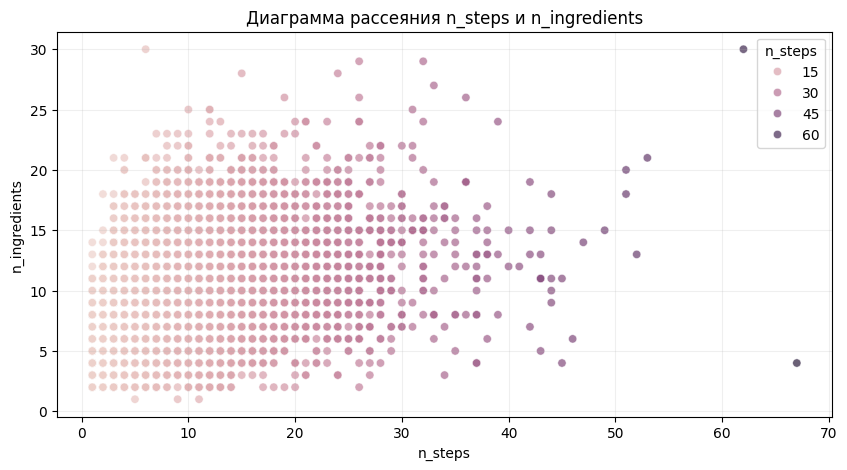

Корреляция (Pearson): 0.41178882757083607


In [23]:
# Диаграмма рассеяния n_steps и n_ingredients с группировкой по длительности рецепта.
scatter_df = recipes.dropna(subset=["n_steps", "n_ingredients"]).copy()

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=scatter_df,
    x="n_steps",
    y="n_ingredients",
    hue="n_steps",
    alpha=0.7
)
plt.title("Диаграмма рассеяния n_steps и n_ingredients")
plt.xlabel("n_steps")
plt.ylabel("n_ingredients")
plt.grid(True, alpha=0.2)
plt.show()

# Численная проверка (для комментария ниже): корреляция между n_steps и n_ingredients
print("Корреляция (Pearson):", scatter_df["n_steps"].corr(scatter_df["n_ingredients"]))


**Комментарий:** визуально наблюдается слабая положительная зависимость: при росте `n_steps` в среднем увеличивается и `n_ingredients`, но разброс значительный, поэтому строгой линейной зависимости не видно.

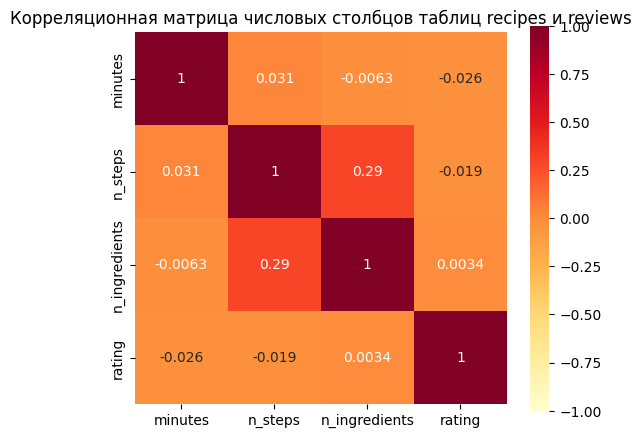

,minutes,n_steps,n_ingredients,rating
minutes,1.000000,0.030675,-0.006254,-0.025770
n_steps,0.030675,1.000000,0.293526,-0.019057
n_ingredients,-0.006254,0.293526,1.000000,0.003405
rating,-0.025770,-0.019057,0.003405,1.000000


In [24]:
# Объединяем таблицы recipes и reviews и строим корреляционную матрицу по числовым столбцам.
merged = pd.merge(
    recipes,
    reviews,
    left_on="id",
    right_on="recipe_id",
    how="inner"
)

cols = ["minutes", "n_steps", "n_ingredients", "rating"]
corr = merged[cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="YlOrRd", vmin=-1, vmax=1, square=True)
plt.title("Корреляционная матрица числовых столбцов таблиц recipes и reviews")
plt.show()

display(corr)
